<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)


In [5]:
iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names


In [6]:
iris_df = pd.DataFrame(X, columns=feature_names)
iris_df['Species'] = y

iris_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
iris_df.shape

(150, 5)

In [8]:
iris_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [9]:
iris_df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [10]:
iris_df['Species'].value_counts()


,count
Species,
0,50
1,50
2,50


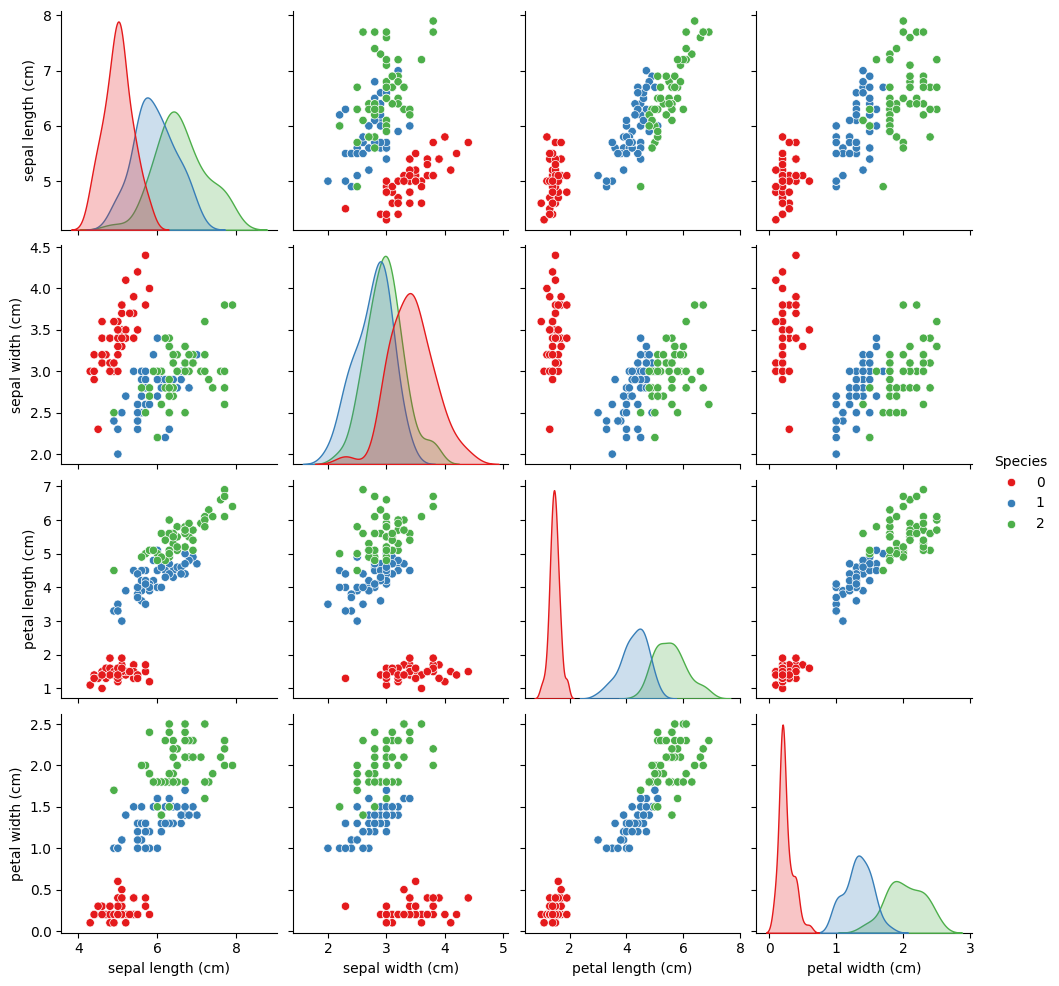

In [11]:
sns.pairplot(iris_df, hue='Species', palette='Set1')
plt.show()


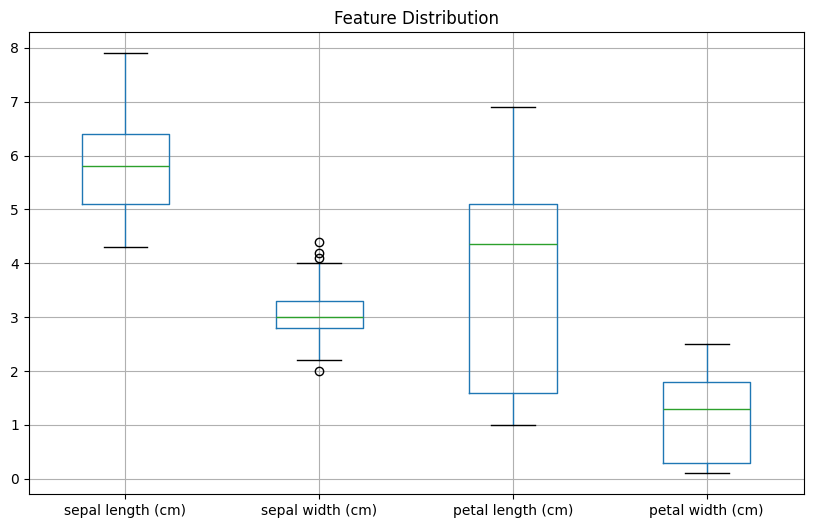

In [12]:
plt.figure(figsize=(10,6))
iris_df.drop(columns='Species').boxplot()
plt.title("Feature Distribution")
plt.show()


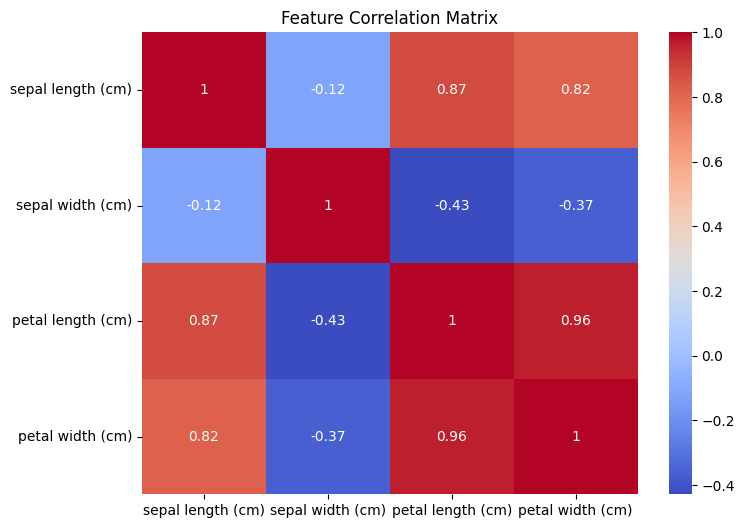

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(
    iris_df.drop(columns='Species').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Matrix")
plt.show()


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [15]:
knn_model = KNeighborsClassifier(
    n_neighbors=5,
    metric='euclidean'
)


In [16]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
precisions = []
recalls = []
f1_scores = []
conf_matrices = []

for train_idx, test_idx in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='macro'))
    recalls.append(recall_score(y_test, y_pred, average='macro'))
    f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    conf_matrices.append(confusion_matrix(y_test, y_pred))


In [17]:
print("Average Accuracy :", np.mean(accuracies))
print("Average Precision:", np.mean(precisions))
print("Average Recall   :", np.mean(recalls))
print("Average F1 Score :", np.mean(f1_scores))


Average Accuracy : 0.9666666666666666
Average Precision: 0.9683501683501683
Average Recall   : 0.9666666666666666
Average F1 Score : 0.9665831244778612


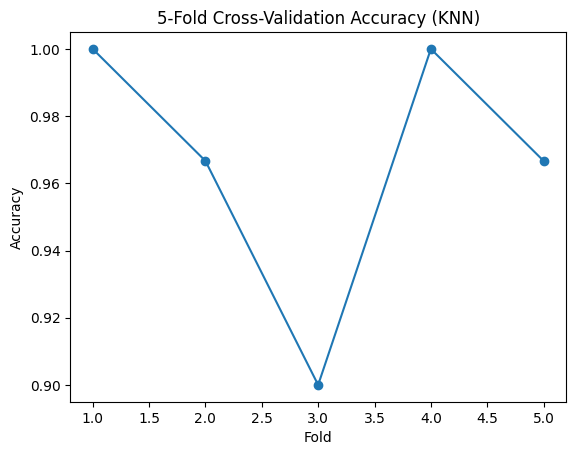

In [18]:
plt.figure()
plt.plot(range(1,6), accuracies, marker='o')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy (KNN)")
plt.show()


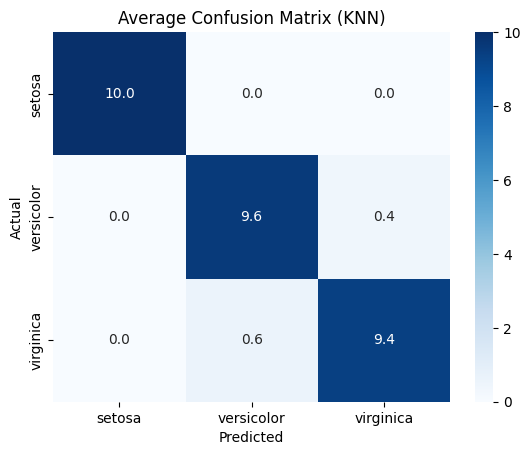

In [19]:
avg_cm = np.mean(conf_matrices, axis=0)

plt.figure()
sns.heatmap(
    avg_cm,
    annot=True,
    fmt='.1f',
    xticklabels=target_names,
    yticklabels=target_names,
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Average Confusion Matrix (KNN)")
plt.show()


In [20]:
X_2d = X_scaled[:, :2]
knn_model.fit(X_2d, y)
y_pred_2d = knn_model.predict(X_2d)


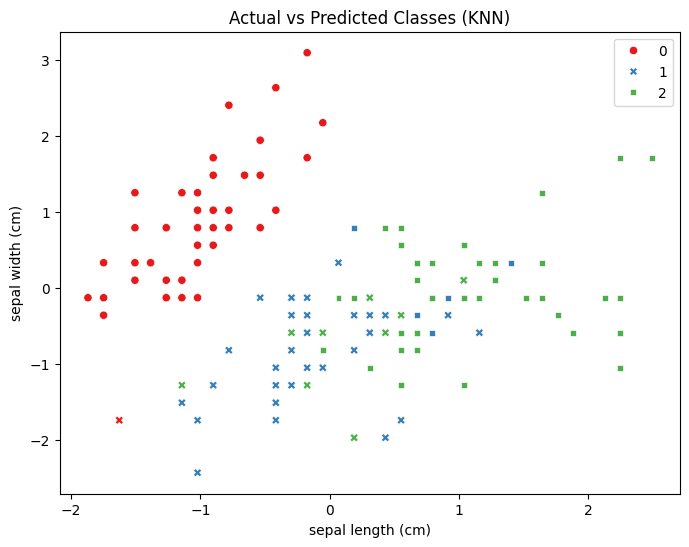

In [21]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=y,
    style=y_pred_2d,
    palette='Set1'
)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Actual vs Predicted Classes (KNN)")
plt.show()


In [22]:
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]


In [23]:
knn_model.fit(X_scaled, y)
y_score = knn_model.predict_proba(X_scaled)


In [24]:
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


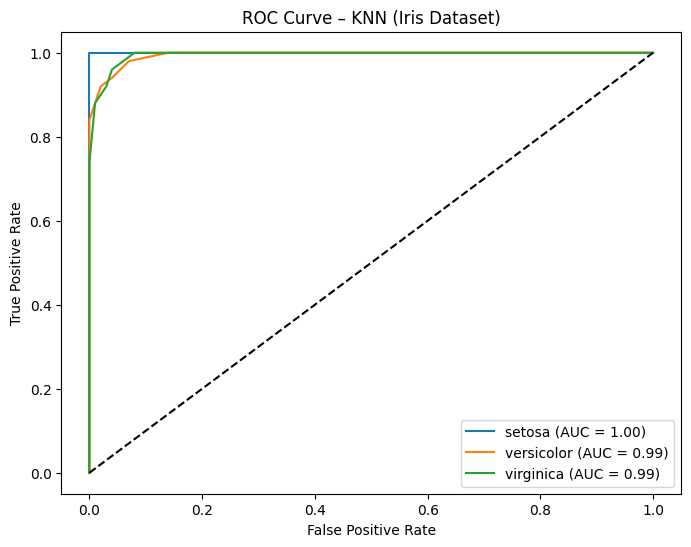

In [25]:
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{target_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – KNN (Iris Dataset)")
plt.legend(loc="lower right")
plt.show()
